# Pokemon Analysis

I used my Pokedex scraper to get Pokemon stats from the Pokedex site. Using that data, I will make some visualizations that give some insights about Pokemons.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import requests
from io import BytesIO
from ipywidgets import HTML, Image, Layout, HBox, VBox
from PIL import Image as PILImage

In [2]:
df = pd.read_json('pokedex.jl', lines=True).sort_values('number')
df['height'] = df['height'] / 12     # convert from inches to feet
df['power'] = df.apply(lambda x: x['hp'] + x['attack'] + x['defense'] + x['special_attack'] + 
                                 x['special_defense'] + x['speed'],
                       axis=1)
df['type1'] = df.apply(lambda x: x['type'][0], axis=1)     # primary type
df['type2'] = df.apply(lambda x: x['type'][1] if len(x['type']) > 1 else x['type'][0], axis=1)     # secondary type
df.head()

,pokemon,number,image,description,height,weight,category,abilities,type,weaknesses,evolutions,hp,attack,defense,special_attack,special_defense,speed,power,type1,type2
0,Bulbasaur,1,https://assets.pokemon.com/assets/cms2/img/pok...,Bulbasaur can be seen napping in bright sunlig...,2.333333,15.2,Seed,{'Overgrow': 'Powers up Grass-type moves when ...,"[Grass, Poison]","[Fire, Psychic, Flying, Ice]","[Bulbasaur, Ivysaur, Venusaur]",3,3,3,4,4,3,20,Grass,Poison
1,Ivysaur,2,https://assets.pokemon.com/assets/cms2/img/pok...,There is a bud on this Pokémon's back. To supp...,3.250000,28.7,Seed,{'Overgrow': 'Powers up Grass-type moves when ...,"[Grass, Poison]","[Fire, Psychic, Flying, Ice]","[Bulbasaur, Ivysaur, Venusaur]",4,4,4,5,5,4,26,Grass,Poison
2,Venusaur,3,https://assets.pokemon.com/assets/cms2/img/pok...,There is a large flower on Venusaur's back. Th...,6.583333,220.5,Seed,{'Overgrow': 'Powers up Grass-type moves when ...,"[Grass, Poison]","[Fire, Psychic, Flying, Ice]","[Bulbasaur, Ivysaur, Venusaur]",5,5,5,6,6,5,32,Grass,Poison
3,Charmander,4,https://assets.pokemon.com/assets/cms2/img/pok...,The flame that burns at the tip of its tail is...,2.000000,18.7,Lizard,{'Blaze': 'Powers up Fire-type moves when the ...,[Fire],"[Water, Ground, Rock]","[Charmander, Charmeleon, Charizard]",3,4,3,4,3,4,21,Fire,Fire
4,Charmeleon,5,https://assets.pokemon.com/assets/cms2/img/pok...,Charmeleon mercilessly destroys its foes using...,3.583333,41.9,Flame,{'Blaze': 'Powers up Fire-type moves when the ...,[Fire],"[Water, Ground, Rock]","[Charmander, Charmeleon, Charizard]",4,4,4,5,4,5,26,Fire,Fire


## Pokemon Primary Types

Currently, there is a total of 890 Pokemons. A Pokemon can have one or two types. For the Pokemons with two types, I define their primary type as the first type that is listed in the Pokedex. For the Pokemons with only one type, I consider their primary type and secondary type to be the same. The bar chart shows the number of Pokemons by their primary type. The most common type is Water and the least common type is Flying.

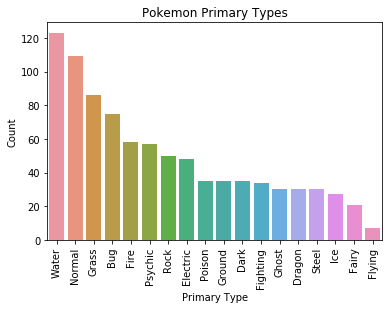

In [3]:
sns.countplot(x='type1', data=df, order=df['type1'].value_counts().index)
plt.xticks(rotation=90)
plt.title('Pokemon Primary Types')
plt.xlabel('Primary Type')
plt.ylabel('Count');

## Pokemon Type Combinations

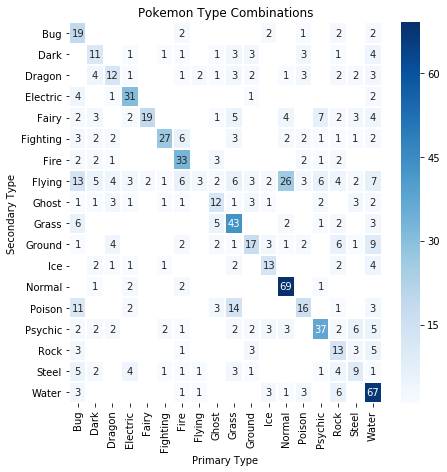

In [4]:
plt.subplots(figsize=(7, 7))
ax = sns.heatmap(pd.pivot_table(df, index='type2', columns='type1', values='pokemon', aggfunc=np.size), 
                 annot=True, cmap="Blues", linewidths=1)
bottom, top = ax.get_ylim()
ax.set_ylim(bottom + 0.5, top - 0.5)
ax.set_title('Pokemon Type Combinations')
ax.set_xlabel('Primary Type')
ax.set_ylabel('Secondary Type');

The heatmap shows that the most common type combination is Normal. The second most common combo is Water. The distinct diagonal shows that most Pokemons only have one type. The most common combination of two different types is Normal and Flying. There are a lot of type combinations that have not yet been used. It will be interesting to see new Pokemons with unused type combinations.

## Pokemon Height & Weight

The scatterplot below shows all the Pokemons' height and weight. Hover over each marker to display an image of the respective Pokemon.

In [5]:
# create plot widget
fig = go.Figure()
for type1 in np.sort(df['type1'].unique()):
    fig.add_trace(go.Scattergl(x=df.loc[df['type1'] == type1, 'height'],
                               y=df.loc[df['type1'] == type1, 'weight'],
                               name=type1,
                               mode='markers',
                               marker=dict(opacity=.45),
                               text=df.loc[df['type1'] == type1, 'pokemon'],
                               hovertemplate= '<b>%{text}</b><br>' +
                                              'Height: %{x:.1f} feet<br>' +
                                              'Weight: %{y:} lbs<br>'))

fig.update_layout(legend_title_text='Primary Type')
fig = go.FigureWidget(fig)
fig.layout.title = 'Pokemon Height & Weight'
fig.layout.xaxis.title = 'Height (feet)'
fig.layout.yaxis.title = 'Weight (lbs)'

# create pokemon name widget
pokemon_name = HTML(df['pokemon'][0])

# create image widget
response = requests.get(df['image'][0])
image_widget = Image(value=BytesIO(response.content).read(),
                     layout=Layout(height='200px', width='200px'))

# update on hover
def hover_update(trace, points, state):
    if not points.point_inds:
        return
    
    #update name
    pokemon = trace.text[points.point_inds[0]]
    pokemon_name.value = pokemon

    #update image
    img = df[df['pokemon'] == pokemon]['image'].values[0]
    image_widget.value = BytesIO(requests.get(img).content).read()

for i in range(len(fig.data)):
    fig.data[i].on_hover(hover_update)

# combine widgets together
HBox([fig, VBox([pokemon_name, image_widget],
                layout=Layout(display='flex', align_items='center'))],
     layout=Layout(display='flex', align_items='center'))

    'data': [{'hovertemplate': '<b>%{text}</b><br>Height: %{x:.1f} feet<br>Weigh…

## Most Powerful Pokemon by Primary Type

To calculate the power of a Pokemon, I used a simple heuristic of adding their stats together. The illustration below shows the most powerful Pokemon by primary type. If there was a tie in a group, I used the special attack and attack stats as the tie breaker. Out of all the Pokemons, Arceus is the most powerful.

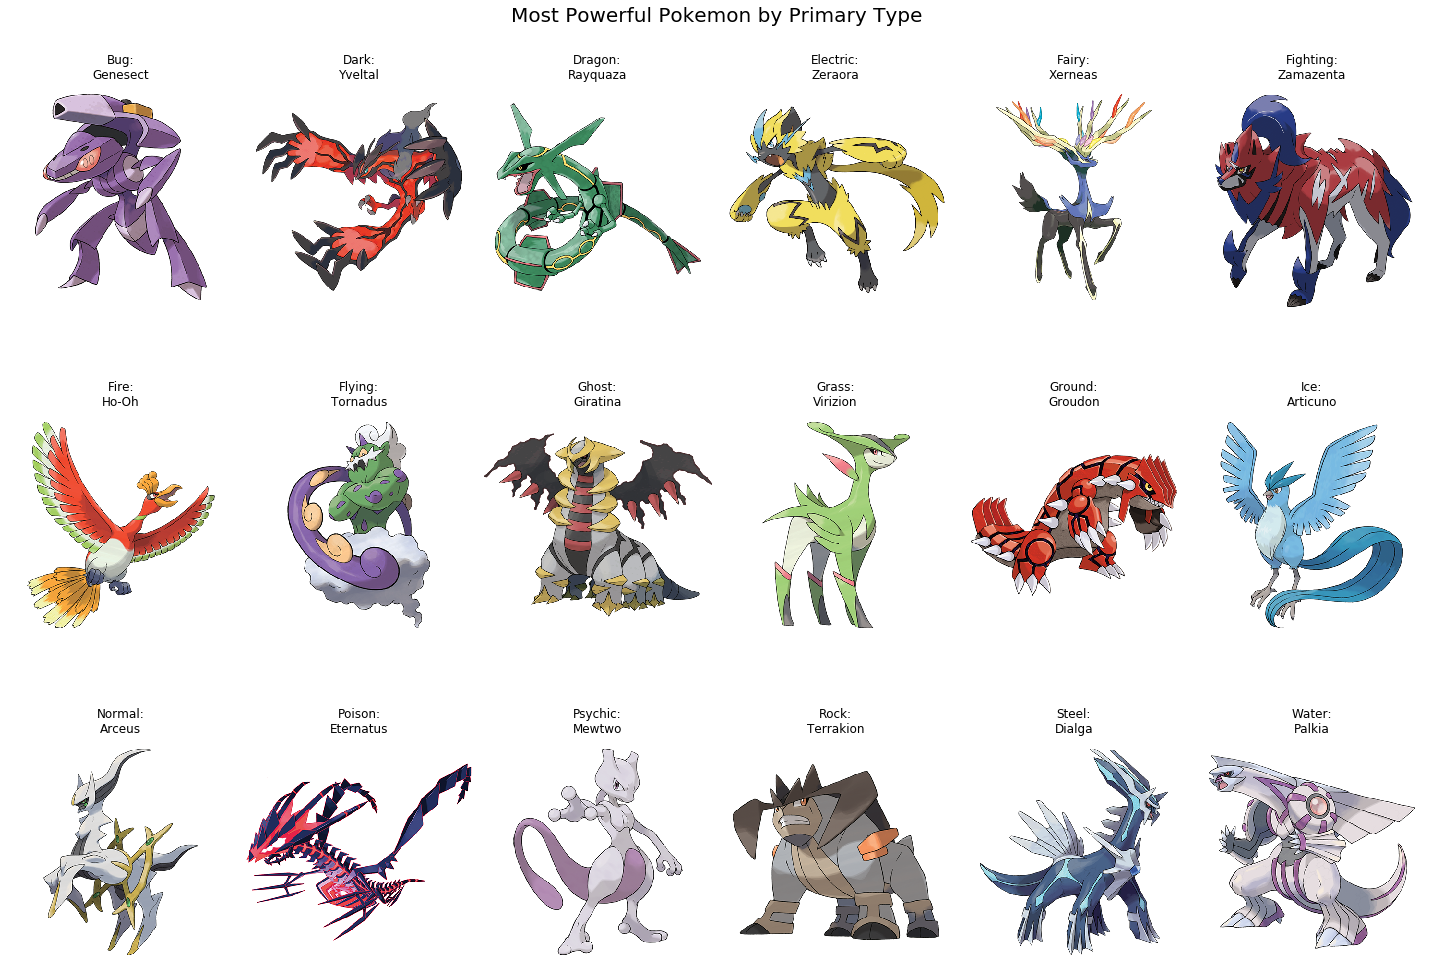

In [6]:
temp = df.sort_values(['type1', 'power', 'special_attack', 'attack'], ascending=[True, False, False, False]).\
                     groupby('type1').first().reset_index()
fig = plt.figure(figsize=(20, 15))
fig.suptitle('Most Powerful Pokemon by Primary Type', size=20)

for index, row in temp.iterrows():
    response = requests.get(row['image'])
    img = PILImage.open(BytesIO(response.content))
    plt.subplot(3, 6, index + 1)
    plt.title(row['type1'] + ':\n' + row['pokemon'])
    plt.axis('off')
    plt.imshow(img)
    
fig.subplots_adjust(top=1)
plt.tight_layout()